In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

df = pd.read_csv(r"C:\Users\vshal\OneDrive\Desktop\Telecom_churn_analytics.csv")

df['International plan'] = df['International plan'].map({'No': 0, 'Yes': 1})

df['Voice mail plan'] = df['Voice mail plan'].map({'No': 0, 'Yes': 1})

df['Churn'] = df['Churn'].astype(int)

df = df.drop('State', axis=1)

X = df.drop('Churn', axis=1)

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [2]:
print(X_train.shape)
print(y_train.shape)

(2132, 18)
(2132,)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [6]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.8408239700374532
Precision: 0.3939393939393939
Recall: 0.16666666666666666
F1 Score: 0.23423423423423423
ROC AUC: 0.7509840305892939


In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.9550561797752809
Precision: 0.9821428571428571
Recall: 0.7051282051282052
F1 Score: 0.8208955223880597
ROC AUC: 0.8682523616734142


In [10]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.840824,0.393939,0.166667,0.234234,0.750984
1,Random Forest,0.955056,0.982143,0.705128,0.820896,0.868252


In [11]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
5,Total day minutes,0.133640
7,Total day charge,0.131748
17,Customer service calls,0.126298
2,International plan,0.090094
10,Total eve charge,0.065757
8,Total eve minutes,0.063406
15,Total intl calls,0.052978
16,Total intl charge,0.044420
14,Total intl minutes,0.044246
11,Total night minutes,0.036665


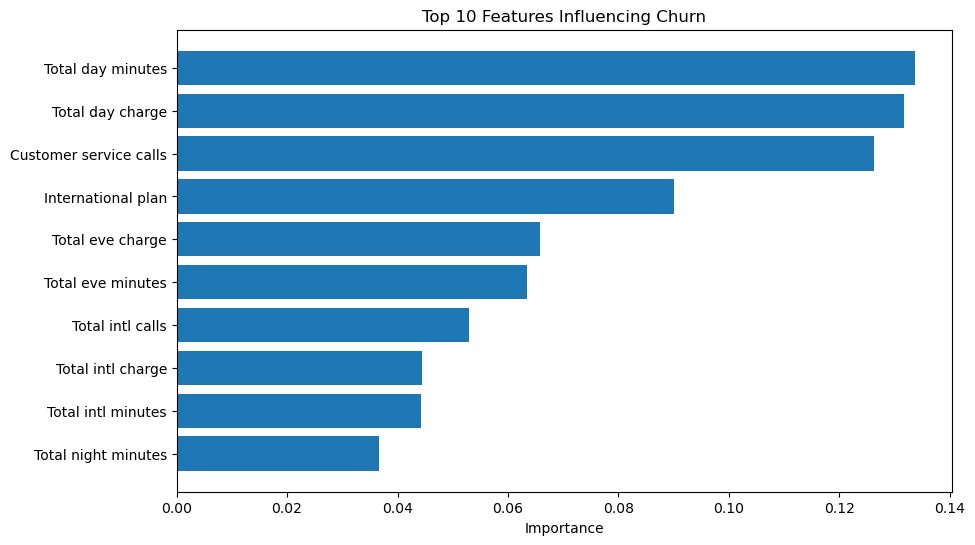

In [12]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10['Feature'], top10['Importance'])

plt.xlabel('Importance')

plt.title('Top 10 Features Influencing Churn')

plt.gca().invert_yaxis()

plt.show()